# Network Anomaly Detection - VNTD

This document trains an **Isolation Forest** model to detect anomalous network traffic from Suricata logs.

### How it works

1. Teach the model what **normal traffic looks like** (using only a benign dataset).
2. Ask the model to evaluate all traffic; anything that looks different from normal is flagged as an anomaly.

### Why train only on benign data?

The `attacks.json` file can contain around 300.000 entries, most of which are DoS flood packets. If we train the model on that, it would think DoS traffic is *normal*. By training only the benign events (much smaller dataset), the model learns what legitimate traffic looks like and everything else becomes suspicious.

### Events

Suricata generates several event types, and each one carries useful information:

| Event type | What it tells us                                                                       |
|------------|----------------------------------------------------------------------------------------|
| `flow`     | Completed connection -> bytes, packets, duration                                       |
| `dns`      | DNS query/response -> domain names being resolved                                      |
| `http`     | HTTP request -> URL, method, status code, response size                                |
| `smtp`     | Email -> sender, recipient                                                             |
| `anomaly`  | Protocol anomaly detected by Suricata                                                  |
| `alert`    | *(excluded by default)* Suricata rule match -> would be "cheating" to use for training |

### Files used

| File                | Description                                                          |
|:--------------------|:---------------------------------------------------------------------|
| `data/benign.json`  | ~240 flows of normal traffic; used to **train** the model            |
| `data/attacks.json` | ~300.000 flows of attack traffic (DoS, port scan, SSH bruteforce...) |
| `data/data.json`    | Combined dataset; used to **evaluate** the model                     |


---

## Step 0 - Configure settings

Define which Suricata event types to load. By default, `alert` is **excluded** because those are events where Suricata has already applied a rule. Using them for training would give the model an unfair advantage (it would be learning from already labelled attacks).

To include or exclude other types, comment / uncomment the lines in `EXCLUDE_TYPES`.

In [1]:
EXCLUDE_TYPES = {
    "alert",                 # Suricata rule match, using this would be "cheating"
    # "anomaly"              # Protocol anomaly detected by suricata
    # "fileinfo"             # File transfer info
}

print("Excluded event types: ", EXCLUDE_TYPES)

Excluded event types:  {'alert'}


---

## Step 1 - Load the data

Suricata writes logs as **JSON Lines**, one JSON object per line. Every event that is not in `EXCLUDE_TYPES` is loaded.

`flatten_json` converts nested dictionaries into flat columns so that all fields are accessible as simple column names. For example:

```json
{"flow": {"age": 5}}
{"answers": [{"data": "192.168.10.10"}]}
```

becomes:
```
 flow_age         5
 answers_0_data   192.168.10.10
```

Because different event types have different fileds, many columns will be `NaN` for rows where that field doesn't apply. Those will later be filled with `0` later.

In [2]:
import json
import pandas as pd

def flatten_json(d, parent_key='', sep='_'):
    """
    Recursively flattens a nested dictionary
    """
    
    items = []

    for k, v in d.items():
        # Build the new key appending the parent path
        new_key = f"{parent_key}{sep}{k}" if parent_key else k

        if isinstance(v, dict):
            #  Recursive into nested dictionaries
            items.extend(flatten_json(v, new_key, sep=sep).items())

        elif isinstance(v, list):
            if len(v) == 0:
                # Empty list -> store as None so the column still exists
                items.append((new_key, None))
            else:
                for i, item in enumerate(v):
                    list_key = f"{new_key}{sep}{i}"

                    if isinstance(item, dict):
                        items.extend(flatten_json(item, list_key, sep=sep).items())
                    else:
                        items.append((list_key, item))
        else:
            items.append((new_key, v))

    return dict(items)

def load_data(file):
    """
    Reads a Suricata eve.json file and returns a DataFrame
    Loads all event types except those defined in EXCLUDE_TYPES
    All nested fields are flattened into columns
    """
    
    rows = []

    with open(file, "r") as f:
        for line in f:
            try:
                event = json.loads(line.strip())
            except json.JSONDecodeError:
                continue # Skip any lines that can not be processed

            # Skip excluded event types
            if event.get("event_type") in EXCLUDE_TYPES:
                continue
                
            rows.append(flatten_json(event))

    return pd.DataFrame(rows)

### Event (of type `flow`) example prior to processing

```json
{
   "timestamp":"2026-04-10T14:03:15.502440+0000",
   "flow_id":1099387108089453,
   "in_iface":"eth1",
   "event_type":"flow",
   "src_ip":"10.0.0.2",
   "src_port":38018,
   "dest_ip":"192.168.10.10",
   "dest_port":22,
   "proto":"TCP",
   "flow":{
      "pkts_toserver":2,
      "pkts_toclient":0,
      "bytes_toserver":128,
      "bytes_toclient":0,
      "start":"2026-04-10T13:58:36.548461+0000",
      "end":"2026-04-10T13:58:36.549139+0000",
      "age":0,
      "state":"new",
      "reason":"timeout",
      "alerted":false
   },
   "community_id":"1:T/hpCH2HdAaBxpHOZeIqbBSQwqo=",
   "tcp":{
      "tcp_flags":"06",
      "tcp_flags_ts":"06",
      "tcp_flags_tc":"00",
      "syn":true,
      "rst":true,
      "state":"syn_sent"
   }
}
```

After flattening the json, the nested dictionaries become flat columns: `flow_pkts_toserver`, `flow_bytes_toserver`, `flow_age`, `tcp_syn`, etc.

In [3]:
# Load each file, big files may take a moment
df_attack = load_data("../data/attacks.json")
df_benign = load_data("../data/benign.json")

# Quick size check
print(f"Attack events: {len(df_attack):>12,}")
print(f"Benign events: {len(df_benign):>12,}")

# Event type breakdown
print("\nAttack - event types:")
print(df_attack["event_type"].value_counts().to_string())

print("\nBenign - event types:")
print(df_benign["event_type"].value_counts().to_string())

Attack events:      299,619
Benign events:          240

Attack - event types:
event_type
flow        299411
dns             84
http            35
fileinfo        34
anomaly         21
ssh             20
smtp            12
tls              2

Benign - event types:
event_type
dns         122
flow         64
http         14
fileinfo     14
anomaly      13
smtp         13


---

## Step 2 - Explore the raw data

Before building anything, it helps to look at what the data actually contains. As event types have different fields, each type is inspected separately. Key things to look for:
- Do attack behave differently from benign in byte/packet counts?
- Are HTTP error codes (405, 404) more common in attacks?
- Are DNS patterns different?

`.describe()` is called on **numeric columns only** for a clean summary.

In [4]:
# Flow events
# After flatten_json, the nested 'flow' elements becomes columns like flow_pkts_toserver
# Comparing statistics may reveal the DoS pattern
flow_cols = [
    "flow_pkts_toserver",
    "flow_pkts_toclient",
    "flow_bytes_toserver",
    "flow_bytes_toclient",
    "flow_age"
]

attack_flows  = df_attack[df_attack["event_type"] == "flow"]
benign_flows  = df_benign[df_benign["event_type"] == "flow"]

print(f"Flow events: {len(benign_flows)} benign / {len(attack_flows)} attack")

if len(attack_flows) > 0:
    print("\nAttack flows statistics:")
    display(attack_flows[flow_cols].describe().round(2))

if len(benign_flows) > 0:
    print("\nBenign flows statistics:")
    display(benign_flows[flow_cols].describe().round(2))

Flow events: 64 benign / 299411 attack

Attack flows statistics:


,flow_pkts_toserver,flow_pkts_toclient,flow_bytes_toserver,flow_bytes_toclient,flow_age
count,299411.00,299411.00,299411.00,299411.00,299411.00
mean,1.15,0.03,76.31,2.19,0.98
std,0.63,0.40,46.15,40.56,3.45
min,1.00,0.00,54.00,0.00,0.00
25%,1.00,0.00,66.00,0.00,0.00
50%,1.00,0.00,66.00,0.00,0.00
75%,1.00,0.00,66.00,0.00,0.00
max,56.00,74.00,5442.00,6733.00,58.00



Benign flows statistics:


,flow_pkts_toserver,flow_pkts_toclient,flow_bytes_toserver,flow_bytes_toclient,flow_age
count,64.00,64.00,64.00,64.00,64.0
mean,3.55,2.89,396.81,326.31,0.0
std,2.99,2.88,431.53,330.79,0.0
min,1.00,0.00,70.00,0.00,0.0
25%,1.00,1.00,72.00,72.00,0.0
50%,1.00,1.00,86.00,88.00,0.0
75%,6.00,4.00,531.00,543.00,0.0
max,8.00,8.00,1193.00,861.00,0.0


In [5]:
# HTTP events
# http_status (200, 404, 500...) and http_length are the most useful numeric fields
attack_http  = df_attack[df_attack["event_type"] == "http"]
benign_http  = df_benign[df_benign["event_type"] == "http"]

print(f"HTTP events: {len(benign_http)} benign / {len(attack_http)} attack")

if len(attack_http) > 0:
    print("\nAttack HTTP status codes:")
    print(attack_http["http_status"].value_counts().to_string())

if len(benign_http) > 0:
    print("\nBenign HTTP status codes:")
    print(benign_http["http_status"].value_counts().to_string())

HTTP events: 14 benign / 35 attack

Attack HTTP status codes:
http_status
405.0    18
200.0     8
404.0     7

Benign HTTP status codes:
http_status
200.0    14


In [6]:
# DNS events
# dns_type (query/answer) and dest_port are the main useful fields
attack_dns  = df_attack[df_attack["event_type"] == "dns"]
benign_dns  = df_benign[df_benign["event_type"] == "dns"]

print(f"DNS events: {len(benign_dns)} benign / {len(attack_dns)} attack")

if len(attack_dns) > 0:
    print("\nAttack DNS query types:")
    print(attack_dns["dns_type"].value_counts().to_string())

if len(benign_dns) > 0:
    print("\nBenign DNS query types:")
    print(benign_dns["dns_type"].value_counts().to_string())

DNS events: 122 benign / 84 attack

Attack DNS query types:
dns_type
query     42
answer    42

Benign DNS query types:
dns_type
query     61
answer    61


In [7]:
# FILEINFO events
# Useful numeric fields: fileinfo_size
attack_fileinfo = df_attack[df_attack["event_type"] == "fileinfo"]
benign_fileinfo = df_benign[df_benign["event_type"] == "fileinfo"]

print(f"FileInfo events: {len(benign_fileinfo)} benign / {len(attack_fileinfo)} attack")

if len(attack_fileinfo) > 0:
    print("\nAttack file sizes:")
    display(attack_fileinfo["fileinfo_size"].describe().round(2))

if len(benign_fileinfo) > 0:
    print("\nBenign file sizes:")
    display(benign_fileinfo["fileinfo_size"].describe().round(2))

FileInfo events: 14 benign / 34 attack

Attack file sizes:


count     34.00
mean     137.38
std       73.16
min       35.00
25%      153.00
50%      157.00
75%      157.00
max      441.00
Name: fileinfo_size, dtype: float64


Benign file sizes:


count    14.0
mean     35.0
std       0.0
min      35.0
25%      35.0
50%      35.0
75%      35.0
max      35.0
Name: fileinfo_size, dtype: float64

> **Note:** *SSH, SMTP, TLS and ANOMALY events do not include any relevant numeric fields to be analyzed here, but their presence matters.*

In [8]:
# Count occurrences of the remaining event types.
for event_type in ["ssh", "smtp", "tls", "anomaly"]:
    n_attack = len(df_attack[df_attack["event_type"] == event_type])
    n_benign = len(df_benign[df_benign["event_type"] == event_type])
    print(f"{event_type.upper()} events: {n_benign} benign / {n_attack} attack")

SSH events: 0 benign / 20 attack
SMTP events: 13 benign / 12 attack
TLS events: 0 benign / 2 attack
ANOMALY events: 13 benign / 21 attack


---

## Step 3 - Encode text fields as numbers

ML models only understand numbers. Several Suricata fields are text strings and must be mapped to integer codes before they can be used as features.

Each mapping is defined as a dictionary. Fields that only exist for certain event types (e.g. `flow_state` is only on `flow` events) are encoded conditionally . Rows where the field is absent get `NaN`, which will later be filled with `0`.

### Fields added in this step

| Column            | What it captures                                       |
|-------------------|--------------------------------------------------------|
| `flow_state_num`  | Connection state: `closed=0` (normal) vs `new=2`       |
| `flow_reason_num` | Why the flow ended: `fin=0` (clean) vs `timeout=2`     |
| `dns_rcode_num`   | DNS response code: `NOERROR=0` (benign) vs `REFUSED=2` |
| `tcp_syn`         | TCP SYN flag: connection initiated                     |
| `tcp_fin`         | TCP FIN flag: connection cleanly closed                |
| `tcp_ack`         | TCP ACK flag: acknowledging received data              |
| `tcp_rst`         | TCP RST flag: connection rejected                      |

In [9]:
# Encoding maps

# Suricata event type
EVENT_TYPE_MAP = {
    "flow":     0,
    "dns":      1,
    "http":     2,
    "smtp":     3,
    "anomaly":  4,
    "ssh":      5,
    "tls":      6,
    "fileinfo": 7,
    "netflow":  8,
}

# Network protocol
PROTO_MAP = {
    "ICMP":      1,
    "TCP":       6,
    "UDP":       17,
    "IPv6-ICMP": 58,
}

# DNS message direction
DNS_TYPE_MAP = {
    "query":  0,
    "answer": 1,
}

# Flow connection state
FLOW_STATE_MAP = {
    "closed": 0,
    "established": 1,
    "new": 2,
    "syn_sent": 3
}

# Why the flow ended
FLOW_REASON_MAP = {
    "fin": 0,
    "rst": 1,
    "timeout": 2,
    "forced": 3
}

# DNS response code
DNS_RCODE_MAP = {
    "NOERROR": 0,
    "NXDOMAIN": 1,
    "REFUSED": 2,
    "SERVFAIL": 3
}

def encode_fields(df):
    """
    Converts text columns into numbers using the maps defined above
    
    - event_type_num : unknown types get 99
    - proto_num      : unknown protocols get 0
    - dns_type_num   : NaN for non-DNS events
    - flow_state_num : NaN for non-flow events; unknown states get 99
    - flow_reason_num: NaN for non-flow events; unknown reasons get 99
    - dns_rcode_num  : NaN for non-DNS events; unknown codes get 0
    - tcp_syn        : 0 (False) for events without a TCP SYN flag
    - tcp_fin        : 0 (False) for events without a TCP FIN flag
    - tcp_ack        : 0 (False) for events without a ACK RST flag
    - tcp_rst        : 0 (False) for events without a TCP RST flag
    """
    
    # Event type: unknown event types get 99
    df["event_type_num"] = df["event_type"].map(EVENT_TYPE_MAP).fillna(99)

    # Protocol: unknown protocols get 0
    df["proto_num"] = df["proto"].map(PROTO_MAP).fillna(0)

    # DNS type: only on DNS events; NaN for everything else
    if "dns_type" in df.columns:
        df["dns_type_num"] = df["dns_type"].map(DNS_TYPE_MAP)
    else:
        df["dns_type_num"] = float("nan")

    # Flow state: only on flow events; 99 for any unknown state
    if "flow_state" in df.columns:
        df["flow_state_num"] = df["flow_state"].map(FLOW_STATE_MAP).fillna(99)
    else:
        df["flow_state_num"] = float("nan")

    # Flow reason: why was closed; 99 for unknown reasons
    if "flow_reason" in df.columns:
        df["flow_reason_num"] = df["flow_reason"].map(FLOW_REASON_MAP).fillna(99)
    else:
        df["flow_reason_num"] = float("nan")

    # DNS response code: only on DNS events; 0 (NOERROR) for non-DNS
    if "dns_rcode" in df.columns:
        df["dns_rcode_num"] = df["dns_rcode"].map(DNS_RCODE_MAP).fillna(0)
    else:
        df["dns_rcode_num"] = float("nan")

    # TCP SYN flag: True when a connection was initiated
    if "tcp_syn" in df.columns:
        df["tcp_syn"] = df["tcp_syn"].fillna(False).astype(int)
    else:
        df["tcp_syn"] = 0

    # TCP FIN flag: True when a connection was cleanly closed
    if "tcp_fin" in df.columns:
        df["tcp_fin"] = df["tcp_fin"].fillna(False).astype(int)
    else:
        df["tcp_fin"] = 0

    # TCP ACK flag: True when acknowledging received data
    if "tcp_ack" in df.columns:
        df["tcp_ack"] = df["tcp_ack"].fillna(False).astype(int)
    else:
        df["tcp_ack"] = 0

    # TCP RST flag: True when a connection was forced rejected
    if "tcp_rst" in df.columns:
        df["tcp_rst"] = df["tcp_rst"].fillna(False).astype(int)
    else:
        df["tcp_rst"] = 0
    
    return df

df_attack = encode_fields(df_attack)
df_benign = encode_fields(df_benign)

print("Encoding done")
print("\nAttack event_type_num distribution:")
print(df_attack["event_type_num"].value_counts().to_string())

print("\nBenign event_type_num distribution:")
print(df_benign["event_type_num"].value_counts().to_string())

Encoding done

Attack event_type_num distribution:
event_type_num
0    299411
1        84
2        35
7        34
4        21
5        20
3        12
6         2

Benign event_type_num distribution:
event_type_num
1    122
0     64
2     14
7     14
4     13
3     13


---

## Step 4a - Derived features

New columns are created from existing metrics to make attack patterns more visible:

| Feature        | Formula                               | What it signals                             |
|----------------|---------------------------------------|---------------------------------------------|
| `bytes_per_pkt`| total bytes ÷ total packets           | Low -> scan (tiny packets)                  |
| `pkt_ratio`    | pkts_toserver ÷ pkts_toclient         | High -> DoS (floods server, no reply)       |
| `bytes_ratio`  | bytes_toserver ÷ bytes_toclient       | High -> one side traffic (DoS/scan pattern) |

These features use the `flow_*` column, for non-flow events (dns, http...) those columns are `NaN` and therefore become `0` after `fillna(0)`.

In [10]:
def add_features(df):
    """
    Add new columns derived from existing traffic metrics
    For non-flow events, flow columns are NaN and will be considered as 0
    lip(lower=1) prevents division by zero when the denominator would be 0
    """

    # Ensure the columns exist, even if no flow events are present
    for col in ["flow_pkts_toserver", "flow_pkts_toclient", "flow_bytes_toserver", "flow_bytes_toclient"]:
        if col not in df.columns:
            df[col] = float("nan")

    total_pkts = df["flow_pkts_toserver"].fillna(0) + df["flow_pkts_toclient"].fillna(0)
    total_bytes = df["flow_bytes_toserver"].fillna(0) + df["flow_bytes_toclient"].fillna(0)

    # Avg bytes per attack (small -> scan traffic)
    df["bytes_per_pkt"] = total_bytes / total_pkts.clip(lower=1)

    # Ratio pkt sent vs received (high might be DoS)
    df["pkt_ratio"] = df["flow_pkts_toserver"].fillna(0) / df["flow_pkts_toclient"].fillna(0).clip(lower=1)

    # Same but for bytes
    df["bytes_ratio"] = df["flow_bytes_toserver"].fillna(0) / df["flow_bytes_toclient"].fillna(0).clip(lower=1)

    return df

df_attack = add_features(df_attack)
df_benign = add_features(df_benign)

print("Features added: bytes_per_pkt, pkt_ratio, bytes_ratio")

Features added: bytes_per_pkt, pkt_ratio, bytes_ratio


---

## Step 4b - Time window features

The features above look at each event **on its own**. But many attacks are not unusual as a single event; they are unusual in **volume**. Such as: `DoS flood`, `Port scan`, `SSH brute force`.

- A single SYN packet to port 80 looks normal.
- 100,000 SYN packets to port 80 in 30 seconds is a DoS flood.

The solution: count **how many similar events happen in the same time window**.

| Feature                           | What it detects                                                |
|-----------------------------------|----------------------------------------------------------------|
| `flows_to_dest_port_wndw`         | DoS: Many connections to the same destination                  |
| `unique_srcs_to_dest_wndw`        | DDoS: many different source IPs targeting the same destination |
| `flows_from_src_wndw`             | Brute force/scan: same IP sends many connections               |
| `unique_dest_ports_from_src_wndw` | Port scan: same IP contacts many different ports               |

In [11]:
def add_time_window_features(df, window_seconds="30s"):
    """
    Add features that count similar events within a time window
    Size of the time window by default is 30 seconds
    """

    # Convert the timestamp string into a datetime object
    df["_ts"] = pd.to_datetime(df["timestamp"])

    # Group events into time window by rounding the timestamp to the nearest window
    df["_window"] = df["_ts"].dt.floor(window_seconds)

    # FEATURE 1 - How many flows went to the same (dest_ip, dest_port)
    # During DoS: gets thousands of connections
    counts_to_dest = (
        df.groupby(["_window", "dest_ip", "dest_port"])
        .size()
        .reset_index(name="flows_to_dest_port_wndw")
    )
    df = df.merge(counts_to_dest, on=["_window", "dest_ip", "dest_port"], how="left")

    # Feature 2 - How many unique source IPs get to the same (dest_ip, dest_port)
    # Normal traffic: 1 or 2 unique IPs | DDoS: hundreds of different IPs
    unique_srcs = (
        df.groupby(["_window", "dest_ip", "dest_port"])["src_ip"]
        .nunique()
        .reset_index(name="unique_srcs_to_dest_wndw")
    )
    df = df.merge(unique_srcs, on=["_window", "dest_ip", "dest_port"], how="left")

    # Feature 3 - How many flows came from the same source IP
    # Normal: few connections | Brute force: hundreds of connection attempts
    counts_from_src = (
        df.groupby(["_window", "src_ip"])
        .size()
        .reset_index(name="flows_from_src_wndw")
    )
    df = df.merge(counts_from_src, on=["_window", "src_ip"], how="left")

    # Feature 4 - How many unique destination ports
    # Normal: connects to port 80, 443, 53 | Port scan: contacts port 1, 2, 3, 4...
    unique_ports = (
        df.groupby(["_window", "src_ip"])["dest_port"]
        .nunique()
        .reset_index(name="unique_dest_ports_from_src_wndw")
    )
    df = df.merge(unique_ports, on=["_window", "src_ip"], how="left")

    # Remove the temporary columns created for grouping
    df = df.drop(columns=["_ts", "_window"])

    return df

# Apply features to both datasets
df_attack = add_time_window_features(df_attack)
df_benign = add_time_window_features(df_benign)

print("Time window features added!")

Time window features added!


---

## Step 5 - Visualize differences

Histograms help visualize distributions for each feature. Blue represent benign traffic and red attack one. A clear separatio of the two colours means the model will have it easier to use those features to distinguish normal from anomalous traffic.

Values are capped at the 99th percentile so that extreme DoS spikes (e.g. hundreds of thousands of packages) don't compress everything else.

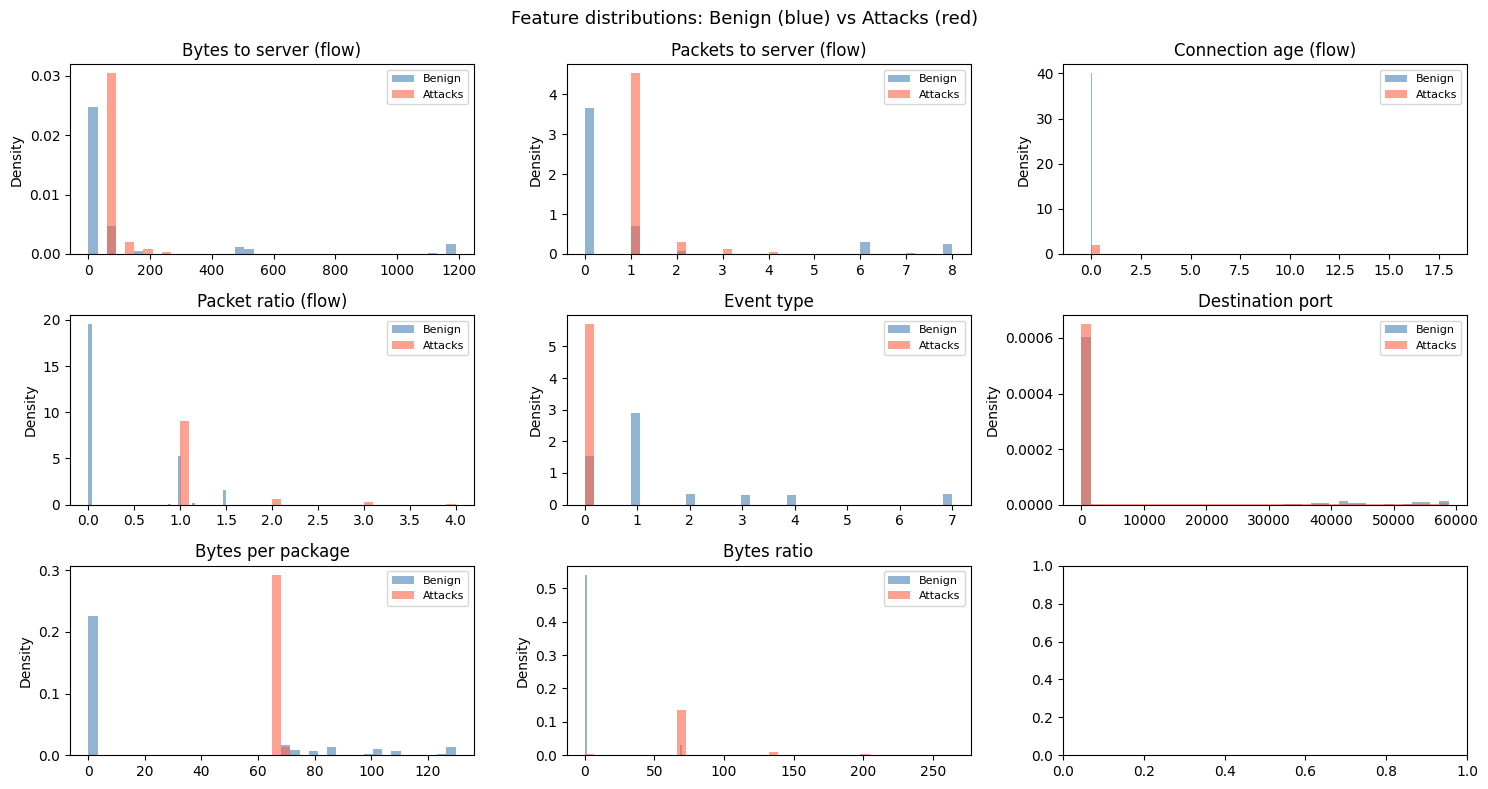

Saved to ../models/feature_distributions.png


In [12]:
import matplotlib.pyplot as plt

features_to_plot = [
    ("flow_bytes_toserver", "Bytes to server (flow)"),
    ("flow_pkts_toserver",  "Packets to server (flow)"),
    ("flow_age",            "Connection age (flow)"),
    ("pkt_ratio",           "Packet ratio (flow)"),
    ("event_type_num",      "Event type"),
    ("dest_port",           "Destination port"),
    ("bytes_per_pkt",       "Bytes per package"),
    ("bytes_ratio",         "Bytes ratio"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
fig.suptitle("Feature distributions: Benign (blue) vs Attacks (red)", fontsize=13)

for ax, (feat, label) in zip(axes.flat, features_to_plot):
    b_vals = df_benign[feat].fillna(0) if feat in df_benign.columns else pd.Series(dtype=float)
    a_vals = df_attack[feat].fillna(0) if feat in df_attack.columns else pd.Series(dtype=float)

    # Cap extreme values at the 99 to avoid 'crushing' the other values
    cap = max(b_vals.quantile(0.99) if len(b_vals) > 0 else 0,
              a_vals.quantile(0.99) if len(a_vals) > 0 else 0)

    ax.hist(b_vals.clip(upper=cap), bins=40, alpha=0.6, color="steelblue", label="Benign",  density=True)
    ax.hist(a_vals.clip(upper=cap), bins=40, alpha=0.6, color="tomato",    label="Attacks", density=True)
    ax.set_title(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../models/feature_distributions.png", dpi=150)
plt.show()

print("Saved to ../models/feature_distributions.png")

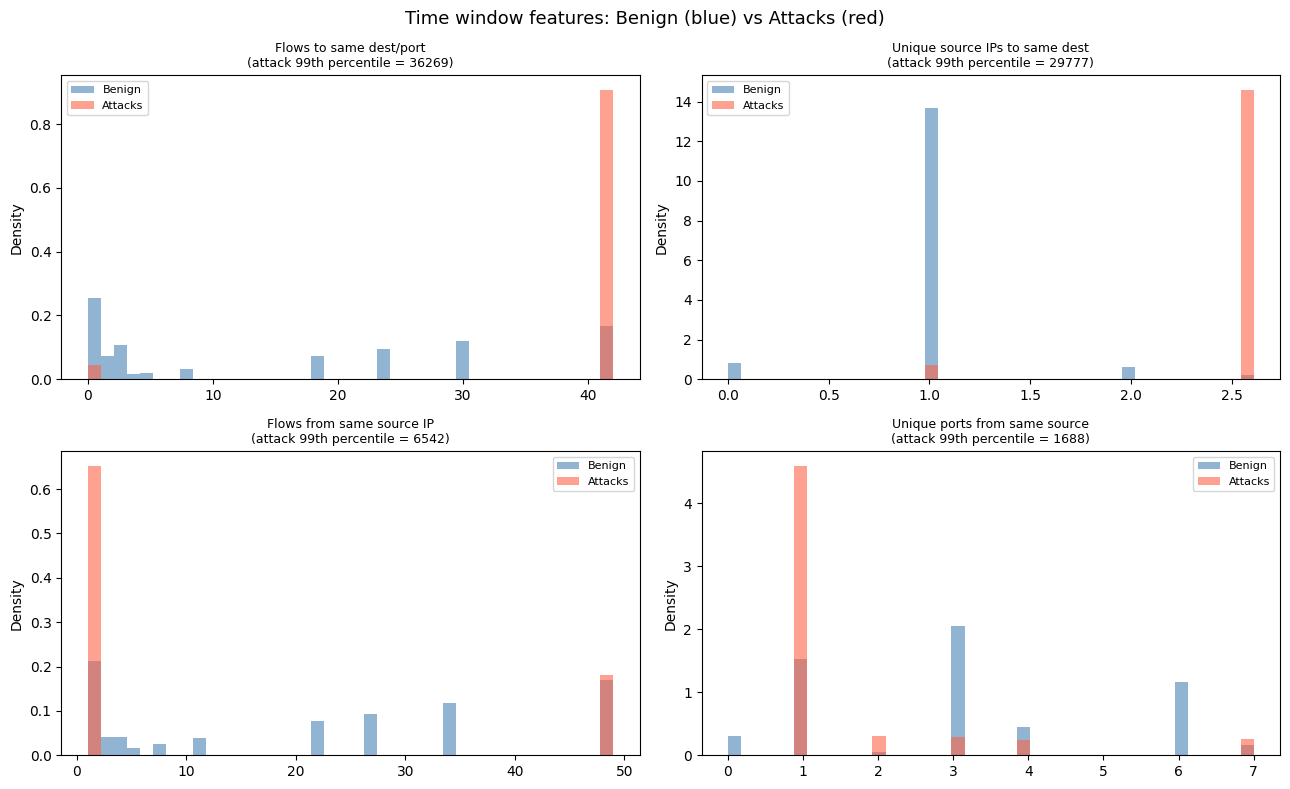

Saved to ../models/time_window_distributions.png


In [13]:
import matplotlib.pyplot as plt

time_window_feats_to_plot = [
    ("flows_to_dest_port_wndw",         "Flows to same dest/port"),
    ("unique_srcs_to_dest_wndw",        "Unique source IPs to same dest"),
    ("flows_from_src_wndw",             "Flows from same source IP"),
    ("unique_dest_ports_from_src_wndw", "Unique ports from same source"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Time window features: Benign (blue) vs Attacks (red)", fontsize=13)

for ax, (feat, label) in zip(axes.flat, time_window_feats_to_plot):
    b_vals = df_benign[feat].fillna(0) if feat in df_benign.columns else pd.Series(dtype=float)
    a_vals = df_attack[feat].fillna(0) if feat in df_attack.columns else pd.Series(dtype=float)

    b_cap = b_vals.quantile(0.99) if len(b_vals) > 0 else 1
    cap = max(b_cap, 1)  # at least 1 to avoid division by zero

    a_p99 = a_vals.quantile(0.99) if len(a_vals) > 0 else 0

    ax.hist(b_vals.clip(upper=cap), bins=40, alpha=0.6, color="steelblue", label="Benign", density=True)
    ax.hist(a_vals.clip(upper=cap), bins=40, alpha=0.6, color="tomato",    label="Attacks", density=True)
    ax.set_title(f"{label}\n(attack 99th percentile = {a_p99:.0f})", fontsize=9)

    
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../models/time_window_distributions.png", dpi=150)
plt.show()

print("Saved to ../models/time_window_distributions.png")

In [14]:
# Quick check at which destionation ports are most common in attacks vs benign
print("Top attack ports:")
print(df_attack["dest_port"].value_counts().head(10).to_string())

print("Top benign ports:")
print(df_benign["dest_port"].value_counts().head(10).to_string())

Top attack ports:
dest_port
80.0       285539
53.0          113
143.0          79
22.0           55
25.0           38
47156.0         4
20538.0         4
48212.0         3
48196.0         3
23877.0         3
Top benign ports:
dest_port
53.0       146
80.0        28
25.0        26
43554.0      1
38490.0      1
38492.0      1
42708.0      1
53578.0      1
53592.0      1
48502.0      1


---

## Step 6 - Select the features

Multiple features are available from multiple event types for the model to be trained on:

| Feature                                     | From          | What it captures                                    |
|---------------------------------------------|---------------|-----------------------------------------------------|
| `event_type_num`                            | all           | What kind of event (flow, dns, http…)               |
| `proto_num`                                 | all           | Network protocol (TCP=6, UDP=17, ICMP=1…)           |
| `src_port`, `dest_port`                     | all           | Source and destination port numbers                 |
| `flow_state_num`                            | flow          | Connection state (closed=0, new=2…)                 |
| `flow_reason_num`                           | flow          | Why the flow ended (fin=0, timeout=2…)              |
| `flow_pkts_toserver/client`                 | flow          | Packet counts in each direction                     |
| `flow_bytes_toserver/client`                | flow          | Byte counts in each direction                       |
| `flow_age`                                  | flow          | Connection duration in seconds                      |
| `bytes_per_pkt`, `pkt_ratio`, `bytes_ratio` | derived       | Traffic asymmetry ratios                            |
| `tcp_syn`, `tcp_fin`, `tcp_ack`, `tcp_rst`  | flow (TCP)    | TCP handshake and termination flags                 |
| `http_status`                               | http          | HTTP response code (200, 404, 500…)                 |
| `http_length`                               | http          | HTTP response body size                             |
| `dns_type_num`                              | dns           | DNS query (0) or answer (1)                         |
| `dns_rcode_num`                             | dns           | DNS response code (NOERROR=0, REFUSED=2…)           |
| `flows_to_dest_port_wndw`                   | time window   | Flows to same dest/port within 30 s (DoS)           |
| `unique_srcs_to_dest_wndw`                  | time window   | Unique source IPs to same dest within 30 s (DDoS)   |
| `flows_from_src_wndw`                       | time window   | Flows from same source IP within 30 s (brute force) |
| `unique_dest_ports_from_src_wndw`           | time window   | Unique ports from same source within 30 s (scan)    |

For events where a feature doesn't exist or is not appliable (e.g. `http_status` on a `flow` event), the value will be `NaN`, which will be processed as 0.

In [15]:
FEATURES = [
    # --- all events ---
    "event_type_num",       # what type of event: flow=0, dns=1, http=2, smtp=3...
    "proto_num",            # network protocol: TCP=6, UDP=17, ICMP=1...
    "src_port",             # source port (NaN for some ICMP events)
    "dest_port",            # destination port
    # --- flow events ---
    "flow_state_num",       # connection state
    "flow_reason_num",      # why the flow ended
    "flow_pkts_toserver",   # packets sent to server
    "flow_pkts_toclient",   # packets sent back to client
    "flow_bytes_toserver",  # bytes sent to server
    "flow_bytes_toclient",  # bytes sent back to client
    "flow_age",             # how long the connection lasted    
    # --- derived from flow ---
    "bytes_per_pkt",        # avg bytes per packet (low = scan traffic)
    "pkt_ratio",            # asymmetry in packet count (high = DoS)
    "bytes_ratio",          # asymmetry in byte count
    # --- TCP flags (flow events only, 0 for UDP/ICMP) ---
    "tcp_syn",              # connection initiation
    "tcp_fin",              # clean connection close
    "tcp_ack",              # acknowledgement
    "tcp_rst",              # forced rejection
    # --- HTTP events ---
    "http_status",          # code: 200 (OK), 404 (not found), 500 (error)...
    "http_length",          # size of the HTTP response body
    # --- DNS events ---
    "dns_type_num",         # 0 = query, 1 = answer (NaN for non-DNS events)
    "dns_rcode_num",        # response code
    # --- time window features ---
    "flows_to_dest_port_wndw",         # count of flows to same destination / port
    "unique_srcs_to_dest_wndw",        # unique IPs targetting same destination
    "flows_from_src_wndw",             # flows from same source IP
    "unique_dest_ports_from_src_wndw", # unique ports scanned by same source
]

# Make sure every column exists (some may be absent if no events of that type exist)
for col in FEATURES:
    if col not in df_benign.columns:
        df_benign[col] = float("nan")
    if col not in df_attack.columns:
        df_attack[col] = float("nan")

# Extract the features to train on (benign data only) and fill missing values with 0
benign_features = df_benign[FEATURES].fillna(0)

print(f"Training data: {benign_features.shape}")
print(f" {benign_features.shape[0]} rows (events)")
print(f" {benign_features.shape[1]} columns (features)")

Training data: (240, 26)
 240 rows (events)
 26 columns (features)


---

## Step 7 - Scale the features

Some features have different magnitudes: `flow_bytes_toserver` can be thousands, while `tcp_syn` is 0 or 1. Without scaling the model would only consider large values and ignore small features because the large ones dominate.

`StandardScaler` makes every feature have **mean = 0** and **standard deviation = 1**.

> **Important:** `fit_transform()` is called **only on the benign training data** to learn the mean and standard deviation. All other data is transformed with `transform()` using those same statistics.

In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# Scale from benign training data and transform it
benign_features_scaled = scaler.fit_transform(benign_features)

# Sanity check, after scaling, mean 0 and std 1
feature_idx = FEATURES.index("flow_bytes_toserver")

print("Before scaling - flow_bytes_toserver:")
print(f"  mean = {benign_features['flow_bytes_toserver'].mean():.1f},  std = {benign_features['flow_bytes_toserver'].std():.1f}")

print("\nAfter scaling - flow_bytes_toserver:")
print(f"  mean = {benign_features_scaled[:, feature_idx].mean():.3f},  std = {benign_features_scaled[:, feature_idx].std():.3f}")

print("\nData sample:")
print(f"  {benign_features_scaled[:5]}")

Before scaling - flow_bytes_toserver:
  mean = 105.8,  std = 282.9

After scaling - flow_bytes_toserver:
  mean = 0.000,  std = 1.000

Data sample:
  [[-0.82113622  3.73155381 -2.03378687 -0.35323749 -1.63018606 -1.6583124
   0.02472041 -0.3944796  -0.12688991 -0.39093061  0.          1.04945065
   1.39795398  4.17708538 -0.3560345  -0.3560345  -0.3560345   0.
  -0.36342189 -0.36342189 -0.58376547 -0.37073003 -1.0072264  -2.65276887
  -1.1160185  -1.56485327]
 [-0.23980084  0.13099591 -0.2740686  -0.34971411  0.60299809  0.60302269
  -0.43165646 -0.3944796  -0.37488323 -0.39093061  0.         -0.58255969
  -0.58919583 -0.25424244 -0.3560345  -0.3560345  -0.3560345   0.
  -0.36342189 -0.36342189 -0.58376547 -0.37073003 -0.50321945 -0.03275023
  -0.56805524  0.45160195]
 [-0.23980084  0.13099591 -0.2740686  -0.34971411  0.60299809  0.60302269
  -0.43165646 -0.3944796  -0.37488323 -0.39093061  0.         -0.58255969
  -0.58919583 -0.25424244 -0.3560345  -0.3560345  -0.3560345   0.
  -0.36

---

## Step 8 - Train the Isolation Forest model

**Isolation Forest** builds many random decision trees:
- **Normal events** look like many others -> hard to isolate -> need many decisions
- **Anomalous events** are unusual -> easy to isolate -> separated in very few decisions

The model assigns an **anomaly score** to each event. More negative = more anomalous. Events below the decision threshold (`offset_`) are flagged.

| Parameter       | Value  | Why                                                |
|-----------------|--------|----------------------------------------------------|
| `n_estimators`  | 12000  | Number of trees -> more = more stable, but slower  |
| `max_samples`   | `auto` | Each tree uses a random sample of the data         |
| `max_features`  | 0.6    | Each tree uses 60% of the features, adds diversity |
| `contamination` | 0.12   | ~12% of training events might be slightly unusual  |
| `random_state`  | 42     | Reproducibility -> same result every run           |
| `n_jobs`        | -1     | Use all available CPU cores, to train faster       |

In [17]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=12000,
    max_samples="auto",
    max_features=0.6,
    contamination=0.12,
    random_state=42,
    n_jobs=-1
)

# Train, using only benign data to learn what benign data looks like
model.fit(benign_features_scaled)

print("Model trained successfully!")
print(f"Trained on {benign_features_scaled.shape[0]} benign events")
print(f"Decision threshold (offset_): {model.offset_:.4f}")
print(" -> Any event with score BELOW this threshold is flagged as an anomaly")

Model trained successfully!
Trained on 240 benign events
Decision threshold (offset_): -0.5614
 -> Any event with score BELOW this threshold is flagged as an anomaly


---

## Step 9 - Save the model

Save both the **scaler** and **model** so later scripts can load and reuse them without retraining from scratch.

`joblib` is included with scikit-learn and allows for saving and loading sklearn objects.

In [18]:
import joblib

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save the model
joblib.dump(model, "../models/isolation_forest.pkl")

# Save the threshold
with open("../models/model_threshold.txt", "w") as f:
    f.write(str(model.offset_))

print("Saved: ")
print("  ../models/scaler.pkl")
print("  ../models/isolation_forest.pkl")

Saved: 
  ../models/scaler.pkl
  ../models/isolation_forest.pkl


---

## Step 10 - Build the evaluation dataset

Tp evaluate the model, it's necessary to have **tagged data**. Such are known benign events (`0`) and known attack events (`1`).

Both DataFrames are already available: `df_benign` and `df_attacks`. Simply add a column to each and concatenate both.

> **Why not use a mixed dataset?** Such datasets that contain a bit of both and have no specific order. There is no sure way of knowing which rows come from where. Using the already loaded `df_benign` and `df_attack` directly is simpler.

In [19]:
# Add tags (0 = normal traffic, 1 =  attack traffic)
df_benign["_label"] = 0
df_attack["_label"] = 1

# Ensure all the columns exist in both before combining
for col in FEATURES:
    if col not in df_benign.columns:
        df_benign[col] = float("nan")
    if col not in df_attack.columns:
        df_attack[col] = float("nan")

# Combine both DataFrames into one evaluation
df_all = pd.concat([df_benign, df_attack], ignore_index=True)

# Extract features and fill missing values with 0
evaluation = df_all[FEATURES].fillna(0)

# Scale using the same scaler on benign data
# Use transform rather than fit_transform since the scaler is already fitted
evaluation_scaled = scaler.transform(evaluation)

# Refer to the actual correct values trying to predict
true_values = df_all["_label"].values

print(f"Evaluation set: {len(df_all):,} events")
print(f"  Normal: {(true_values == 0).sum():,}")
print(f"  Attack: {(true_values == 1).sum():,}")

Evaluation set: 299,859 events
  Normal: 240
  Attack: 299,619


---

## Step 11 - Predictions

The model is asked to classify every event in the evaluation dataset. Two outputs are produced:

- **`predict()`** - binary decision: `1` (normal) or `-1` (anomaly) per event
- **`score_samples()`** - a continuous anomaly score; more negative = more suspicious

In [20]:
# Returns 1 for normal or -1 for anomaly
raw_predictions = model.predict(evaluation_scaled)

# score_samples() returns a continuous score, more negative -> higher chance of abnormal traffic
score = model.score_samples(evaluation_scaled)

# Convert [1, -1] to [0, 1] so that 1 means "anomaly"
prediction = (raw_predictions == -1).astype(int)

print(f"Events flagged as anomalies: {prediction.sum():,} out of {len(prediction):,}")

Events flagged as anomalies: 296,663 out of 299,859


---

## Step 12a - Score distribution diagnostic

Before looking at precision/recall, it helps to visualise **how well the model separates the two classes** at the score level.

- If the attack score distribution sits on the **left** (more negative) of the benign distribution, the model has learned propperly.
- The dashed line shows where the automatic threshold (`offset_`) was placed.
- Events to the **left** of the line are flagged as anomalies.

A gap between the two distributions is a good sign. Overlap means the model will struggle to distinguish the two classes.

Benign  score - mean: -0.491, min: -0.651, max: -0.403
Attack  score - mean: -0.579,  min: -0.667,  max: -0.424
Decision threshold:   -0.561

A large gap between benign and attack means means the model separates them well.


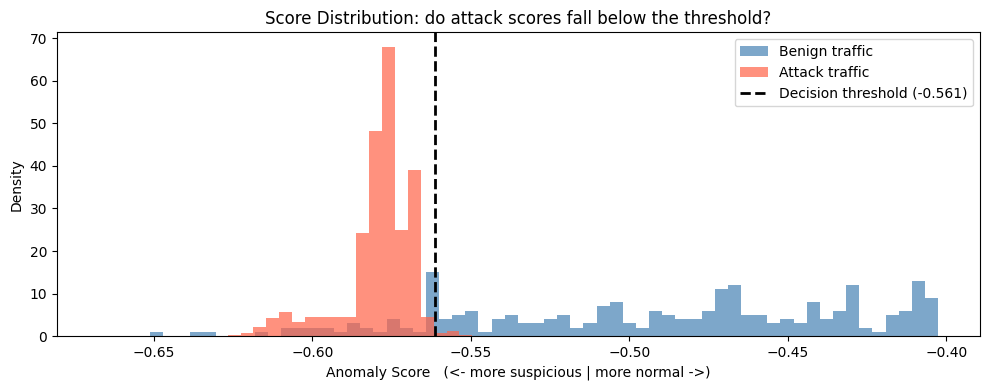

Saved to ../models/score_distribution.png


In [21]:
import matplotlib.pyplot as plt

# Separate the scores by true label
scores_benign = score[true_values == 0]
scores_attack  = score[true_values == 1]

print(f"Benign  score - mean: {scores_benign.mean():.3f}, min: {scores_benign.min():.3f}, max: {scores_benign.max():.3f}")
print(f"Attack  score - mean: {scores_attack.mean():.3f},  min: {scores_attack.min():.3f},  max: {scores_attack.max():.3f}")
print(f"Decision threshold:   {model.offset_:.3f}")
print()
print("A large gap between benign and attack means means the model separates them well.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_benign, bins=60, alpha=0.7, color="steelblue", density=True, label="Benign traffic")
ax.hist(scores_attack,  bins=60, alpha=0.7, color="tomato",    density=True, label="Attack traffic")
ax.axvline(model.offset_, color="black", linestyle="--", linewidth=2, label=f"Decision threshold ({model.offset_:.3f})")
ax.set_xlabel("Anomaly Score   (<- more suspicious | more normal ->)")
ax.set_ylabel("Density")
ax.set_title("Score Distribution: do attack scores fall below the threshold?")
ax.legend()
plt.tight_layout()
plt.savefig("../models/score_distribution.png", dpi=150)
plt.show()
print("Saved to ../models/score_distribution.png")

---

## Step 12b - Report

This report summarises the models performance using the default threshold:

- **Precision** - Of all events flagged as attacks, how many actually were?
- **Recall** - Of all real attacks, how many did we catch?
- **F1-score** - Balance between precision and recall

In a security environment, catching attacks (recall) is usually more important than avoiding false alarms (precision), because missing a real attack is tipically more costly than investigating a false positive.

In [22]:
from sklearn.metrics import classification_report

print(classification_report(true_values, prediction, target_names=["Normal", "Attack"]))

              precision    recall  f1-score   support

      Normal       0.07      0.88      0.12       240
      Attack       1.00      0.99      0.99    299619

    accuracy                           0.99    299859
   macro avg       0.53      0.94      0.56    299859
weighted avg       1.00      0.99      0.99    299859



---

## Step 13 - Confusion Matrix

Break down predictions into four categories:

| Cell               | Meaning                                     |
|--------------------|---------------------------------------------|
| **True Positive**  | Attack correctly detected                   |
| **True Negative**  | Normal traffic correctly ignored            |
| **False Positive** | Normal traffic wrongly flagged as an attack |
| **False Negative** | Attack that slipped undetected              |

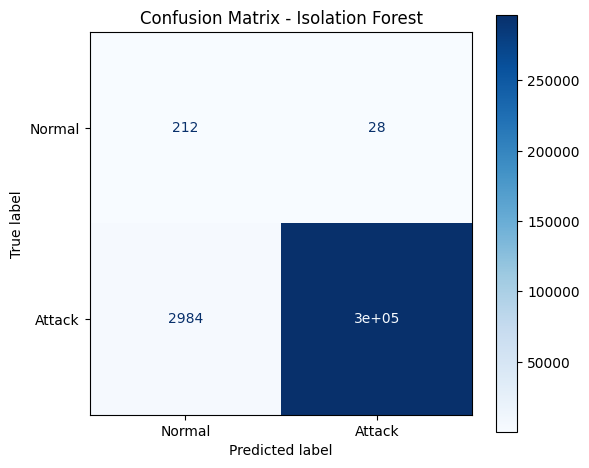

Saved to ../models/confussion_matrix.png


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_values, prediction)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"]).plot(
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix - Isolation Forest")

plt.tight_layout()
plt.savefig("../models/confussion_matrix.png", dpi=150)
plt.show()

print("Saved to ../models/confussion_matrix.png")

---

## Step 14 - ROC curve

The **ROC (Receiver Operating Characteristic) curve** shows model performance on *all possible* decision thresholds, not just the one automatically chosen.

- **X-axis (FPR):** False Positive Rate, benign events wrongly flagged as attacks
- **Y-axis (TPR / Recall):** True Positive Rate, fraction of real attacks that were caught
- **AUC (Area Under the Curve):** Single number, `1.0` = perfect, `0.5` = random guessing

> A high AUC means the anomaly *scores* are meaningful and well-separated.

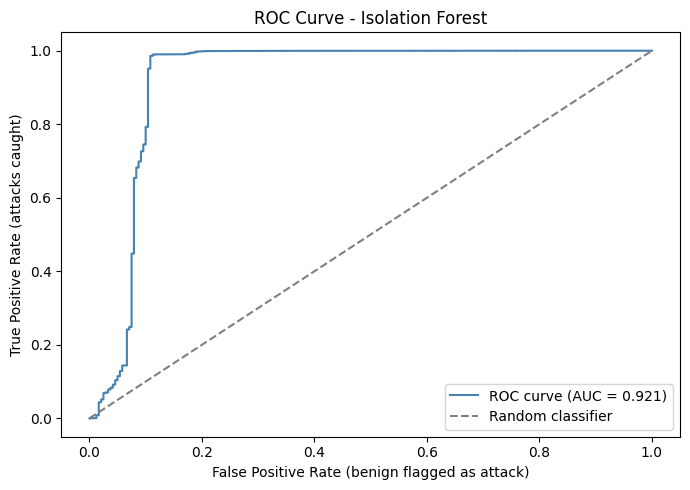

AUC: 0.9212


In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(true_values, -score)  # negate: lower score = more anomalous
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
ax.set_xlabel("False Positive Rate (benign flagged as attack)")
ax.set_ylabel("True Positive Rate (attacks caught)")
ax.set_title("ROC Curve - Isolation Forest")
ax.legend()
plt.tight_layout()
plt.savefig("../models/roc_curve.png", dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")